In [1]:
import requests
import time

In [2]:
!pip install requests

In [3]:
import requests


url = "https://eu.thingsboard.cloud/api/auth/login"


credentials = {
    "username": "antonio.antunovic@ferit.hr",
    "password": "fibonacci112358"
}

# Login request
response = requests.post(url, json=credentials)

if response.status_code == 200:
    data = response.json()
    jwt_token = data["token"]
    print("JWT token:", jwt_token)
else:
    print("Error:", response.status_code, response.text)



JWT token: eyJhbGciOiJIUzUxMiJ9.eyJzdWIiOiJhbnRvbmlvLmFudHVub3ZpY0BmZXJpdC5ociIsInVzZXJJZCI6IjAwOTgyNzIwLTlmN2ItMTFlZi1hNjc3LTdkZjNmNTdiZjlmOSIsInNjb3BlcyI6WyJURU5BTlRfQURNSU4iXSwic2Vzc2lvbklkIjoiZWU5ZTE3MjMtOTAzYS00NDcwLWJhNDgtYjdiYWVjYzAxZmI3IiwiZXhwIjoxNzc1ODMyNTkwLCJpc3MiOiJldS50aGluZ3Nib2FyZC5jbG91ZCIsImlhdCI6MTc3NTgwMzc5MCwiZmlyc3ROYW1lIjoiQW50b25pbyIsImxhc3ROYW1lIjoiQW50dW5vdmljIiwiZW5hYmxlZCI6dHJ1ZSwiaXNQdWJsaWMiOmZhbHNlLCJpc0JpbGxpbmdTZXJ2aWNlIjpmYWxzZSwicHJpdmFjeVBvbGljeUFjY2VwdGVkIjp0cnVlLCJ0ZXJtc09mVXNlQWNjZXB0ZWQiOnRydWUsInRlbmFudElkIjoiMDAxNzM3NTAtOWY3Yi0xMWVmLWE2NzctN2RmM2Y1N2JmOWY5IiwiY3VzdG9tZXJJZCI6IjEzODE0MDAwLTFkZDItMTFiMi04MDgwLTgwODA4MDgwODA4MCJ9.x_kibgp5Mce34KFxm7rFylCs1TDAn6jtQXCsgFzxNtTq1E-BFts6Yy1aQpwhruhg5z6r46BOWY_EB2jewsOqhg


In [6]:
import requests
import time
from datetime import datetime, timedelta, UTC

# Konfiguracija
THINGSBOARD_URL = "https://eu.thingsboard.cloud"
DEVICE_ID = "1043c890-3256-11f1-b641-ab83ce7b9a6f"
JWT_TOKEN = jwt_token  # pretpostavljam da si JWT token već definirao

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {JWT_TOKEN}"
}

# Vrijeme zadnjih 5 minuta
end_date = datetime.now(UTC)
start_date = end_date - timedelta(minutes=6)

# Pretvori u milisekunde
startTs = int(start_date.timestamp() * 1000)
endTs = int(end_date.timestamp() * 1000)

# URL za dohvat telemetrije
url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{DEVICE_ID}/values/timeseries"
params = {
    "keys": "SHT31",
    "startTs": startTs,
    "endTs": endTs,
    "limit": 50000
}

# GET zahtjev
response = requests.get(url, headers=headers, params=params)

print(f"Status Code: {response.status_code}")
print(f"Response Text: {response.text}")

if response.status_code == 200:
    try:
        data = response.json()
        print("Uspješno dohvaćeni podaci.")

        # Dodatno - prikaz broja zapisa
        if "SHT31" in data:
            print(f"Broj zapisa: {len(data['SHT31'])}")
    except ValueError as e:
        print(f"Greška pri parsiranju JSON-a: {e}")
else:
    print(f"Greška pri dohvaćanju podataka: {response.status_code}")

Status Code: 200
Response Text: {"SHT31":[{"ts":1775804081216,"value":"{\"temperature\":23.21,\"humidity\":23.57}"},{"ts":1775804078454,"value":"{\"temperature\":23.21,\"humidity\":23.6}"},{"ts":1775804075707,"value":"{\"temperature\":23.21,\"humidity\":23.63}"},{"ts":1775804072955,"value":"{\"temperature\":23.21,\"humidity\":23.63}"},{"ts":1775804070198,"value":"{\"temperature\":23.2,\"humidity\":23.63}"},{"ts":1775804067450,"value":"{\"temperature\":23.21,\"humidity\":23.54}"},{"ts":1775804064658,"value":"{\"temperature\":23.2,\"humidity\":23.58}"},{"ts":1775804061894,"value":"{\"temperature\":23.22,\"humidity\":23.6}"},{"ts":1775804059054,"value":"{\"temperature\":23.22,\"humidity\":23.61}"},{"ts":1775804056268,"value":"{\"temperature\":23.21,\"humidity\":23.63}"},{"ts":1775804053506,"value":"{\"temperature\":23.2,\"humidity\":23.58}"},{"ts":1775804050748,"value":"{\"temperature\":23.22,\"humidity\":23.64}"},{"ts":1775804047995,"value":"{\"temperature\":23.21,\"humidity\":23.62}"},{

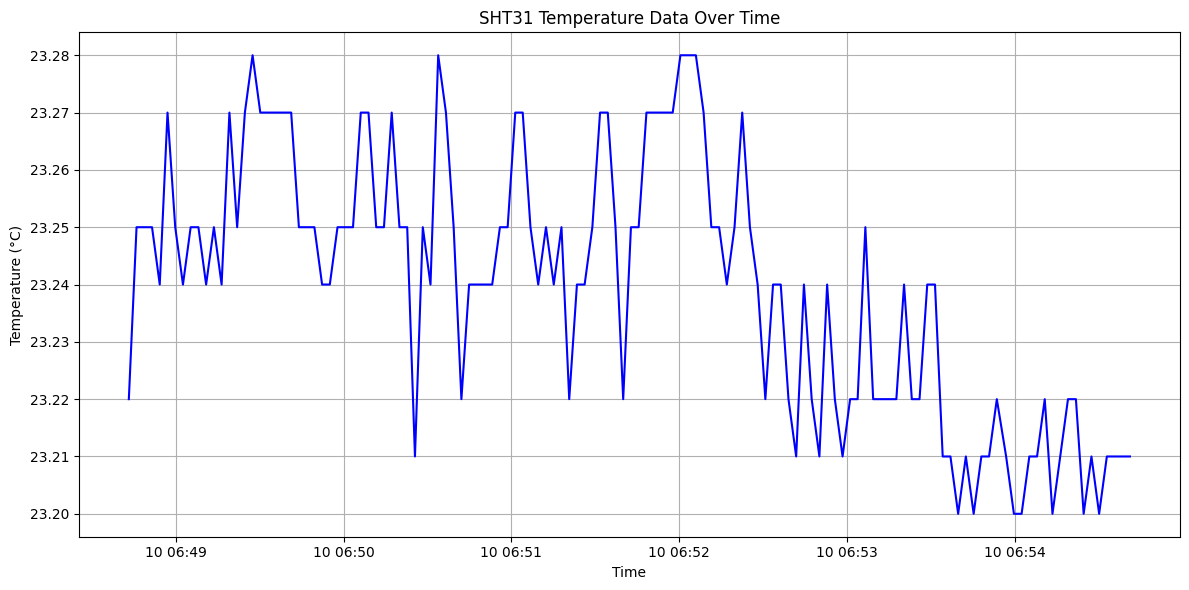

In [7]:
import matplotlib.pyplot as plt
import json
from datetime import datetime

# Extract timestamps and values from the data
timestamps = []
temperature_values = []

# Iterate over the list of data points under the 'SHT31' key
for entry in data['SHT31']:
    # Convert timestamp from milliseconds to datetime object
    timestamps.append(datetime.fromtimestamp(entry['ts'] / 1000))
    # Parse the JSON string value and extract temperature
    value_dict = json.loads(entry['value'])
    temperature_values.append(float(value_dict['temperature']))


# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(timestamps, temperature_values, linestyle='-', color='b')

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('SHT31 Temperature Data Over Time')
plt.grid(True)
plt.tight_layout()  # Adjust layout for better display
plt.show()

### Real-time Temperature Monitoring

This cell will continuously fetch the latest SHT31 temperature data and update a plot in real-time. The data will be refreshed every 5 seconds. To stop the execution, you will need to interrupt the kernel.

In [8]:
import matplotlib.pyplot as plt
import json
from datetime import datetime, timedelta, UTC
import time

# Enable interactive plot mode for live updates
plt.ion()

# Setup the plot
fig, ax = plt.subplots(figsize=(12, 6))
line, = ax.plot([], [], 'b-') # Initialize an empty plot

ax.set_xlabel('Time')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Real-time SHT31 Temperature Data')
ax.grid(True)

try:
    while True:
        # Fetch data for the last 5 minutes
        end_date = datetime.now(UTC)
        start_date = end_date - timedelta(minutes=5)

        startTs = int(start_date.timestamp() * 1000)
        endTs = int(end_date.timestamp() * 1000)

        url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{DEVICE_ID}/values/timeseries"
        params = {
            "keys": "SHT31",
            "startTs": startTs,
            "endTs": endTs,
            "limit": 50000
        }

        response = requests.get(url, headers=headers, params=params)

        if response.status_code == 200:
            try:
                current_data = response.json()
                timestamps = []
                temperature_values = []

                if "SHT31" in current_data:
                    for entry in current_data['SHT31']:
                        timestamps.append(datetime.fromtimestamp(entry['ts'] / 1000))
                        value_dict = json.loads(entry['value'])
                        temperature_values.append(float(value_dict['temperature']))

                    # Update the plot only if there is data
                    if timestamps and temperature_values:
                        line.set_data(timestamps, temperature_values)
                        ax.relim() # Recalculate limits
                        ax.autoscale_view(True,True,True) # Autoscale
                        fig.canvas.draw()
                        fig.canvas.flush_events()
                        print(f"Plot updated at {datetime.now().strftime('%H:%M:%S')}")
                    else:
                        print("No SHT31 data received to plot.")

            except ValueError as e:
                print(f"Error parsing JSON: {e}")
        else:
            print(f"Error fetching data: {response.status_code} - {response.text}")

        time.sleep(5) # Wait for 5 seconds before fetching again

except KeyboardInterrupt:
    print("Real-time plotting stopped.")
    plt.ioff() # Turn off interactive mode
    plt.close(fig) # Close the figure


Plot updated at 06:55:47
Plot updated at 06:55:53
Plot updated at 06:55:59
Plot updated at 06:56:05
Plot updated at 06:56:10
Plot updated at 06:56:16
Plot updated at 06:56:22
Real-time plotting stopped.
